In [1]:

import pickle
import os
os.chdir(r"C:\Users\angel\Desktop\Proyectos_privados\PROYECTOS\EasyMoney_Capstone")
from scipy.stats import chi2_contingency
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder
from src.utils import *
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, f1_score, recall_score, roc_curve, precision_score
from sklearn.model_selection import GridSearchCV
import json
import joblib
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn import set_config

pd.set_option('display.max_columns', None)

set_config(transform_output="pandas")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)


## 1. Carga de data procesada , imputada y limpia

In [2]:
dev_df = pd.read_csv(
    "data/processed/output_data_enriquesida_muestra_limpia_develop.csv", sep="|", low_memory=False)
val_df = pd.read_csv(
    "data/processed/output_data_enriquesida_muestra_limpia_validacion.csv",  sep="|", low_memory=False)


In [3]:
dev_df_X, dev_df_y, val_df_X, val_df_y = import_dev_val(
    dev_df, val_df, target="sales_account")


## 2. Resalizar el split de train y test en develop

In [4]:
X_train, X_test, Y_train, Y_test = split_dev(dev_df_X, dev_df_y)


## 3. Carga de modelo seleccionado

In [5]:

name_model = "RandomForestClassifier"

with open(f"results/model/logaritmo/{name_model}.pkl", "rb") as f:
    model = pickle.load(f)


## 3. Hiperparametros , target , optimizador

In [6]:
target = "sales_account"
scoring = 'f1'

# para XGBoost
# param_grid = {'n_estimators': [100, 400], 'max_depth': [5, 10, 15]}

# para RandomForestClassifier
param_grid = {
    'max_depth': [10, 15],
    'min_samples_leaf': [20, 50]
}

# para DecisionTreeClassifier
# param_grid = {
#     'max_depth': [5, 10, 15],
#     'min_samples_split': [2, 10, 50],
#     'min_samples_leaf': [1, 5, 10]
# }


## 4. Evaluacion de metricas del modelo

Mejores parámetros: {'max_depth': 15, 'min_samples_leaf': 20}
Mejor F1 promedio: 0.6759786999052032

TRAIN -> Accuracy: 0.877, Precision: 0.574, Recall: 0.861, F1: 0.689, ROC AUC: 0.945
Matriz de confusión:
[[173635  23542]
 [  5137  31696]] 

TEST  -> Accuracy: 0.874, Precision: 0.564, Recall: 0.854, F1: 0.679, ROC AUC: 0.941
Matriz de confusión:
[[43282  6056]
 [ 1336  7829]] 

VALID -> Accuracy: 0.864, Precision: 0.481, Recall: 0.825, F1: 0.608, ROC AUC: 0.925
Matriz de confusión:
[[40997  6118]
 [ 1201  5674]] 



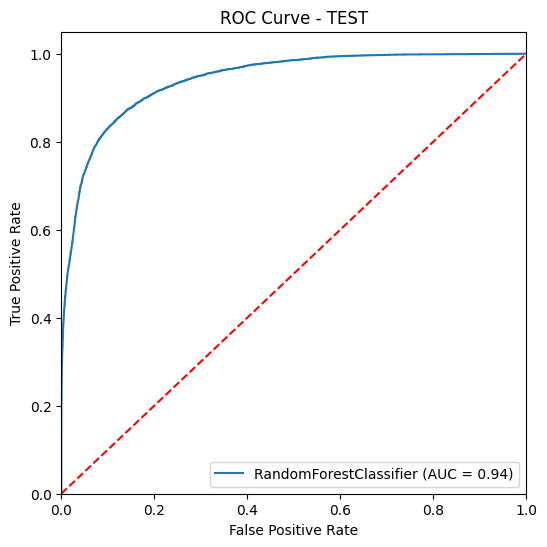

In [7]:
pipeline_evaluacion(X_train, X_test, Y_train, Y_test, val_df_X, val_df_y, scoring, model, param_grid, act=False)



In [8]:
df = pd.read_csv("results/metrics/model_metrics.csv",
                 sep=",", low_memory=False)

df[df["Nombre_Modelo"] == str(model.__class__.__name__)]


,Nombre_Modelo,timestamp,PROCESO,METRICA,VALOR,Comentario
45,RandomForestClassifier,2026-03-17 22:53:01,TRAIN,Accuracy,0.8770,"{'max_depth': 15, 'min_samples_leaf': 20}"
46,RandomForestClassifier,2026-03-17 22:53:01,TRAIN,Precision,0.5740,"{'max_depth': 15, 'min_samples_leaf': 20}"
47,RandomForestClassifier,2026-03-17 22:53:01,TRAIN,Recall,0.8610,"{'max_depth': 15, 'min_samples_leaf': 20}"
48,RandomForestClassifier,2026-03-17 22:53:01,TRAIN,F1,0.6890,"{'max_depth': 15, 'min_samples_leaf': 20}"
49,RandomForestClassifier,2026-03-17 22:53:01,TRAIN,ROC_AUC,0.9450,"{'max_depth': 15, 'min_samples_leaf': 20}"
50,RandomForestClassifier,2026-03-17 22:53:01,TEST,Accuracy,0.8740,"{'max_depth': 15, 'min_samples_leaf': 20}"
51,RandomForestClassifier,2026-03-17 22:53:01,TEST,Precision,0.5640,"{'max_depth': 15, 'min_samples_leaf': 20}"
52,RandomForestClassifier,2026-03-17 22:53:01,TEST,Recall,0.8540,"{'max_depth': 15, 'min_samples_leaf': 20}"
53,RandomForestClassifier,2026-03-17 22:53:01,TEST,F1,0.6790,"{'max_depth': 15, 'min_samples_leaf': 20}"
54,RandomForestClassifier,2026-03-17 22:53:01,TEST,ROC_AUC,0.9410,"{'max_depth': 15, 'min_samples_leaf': 20}"


## 5. Evaluacion de peso de columnas

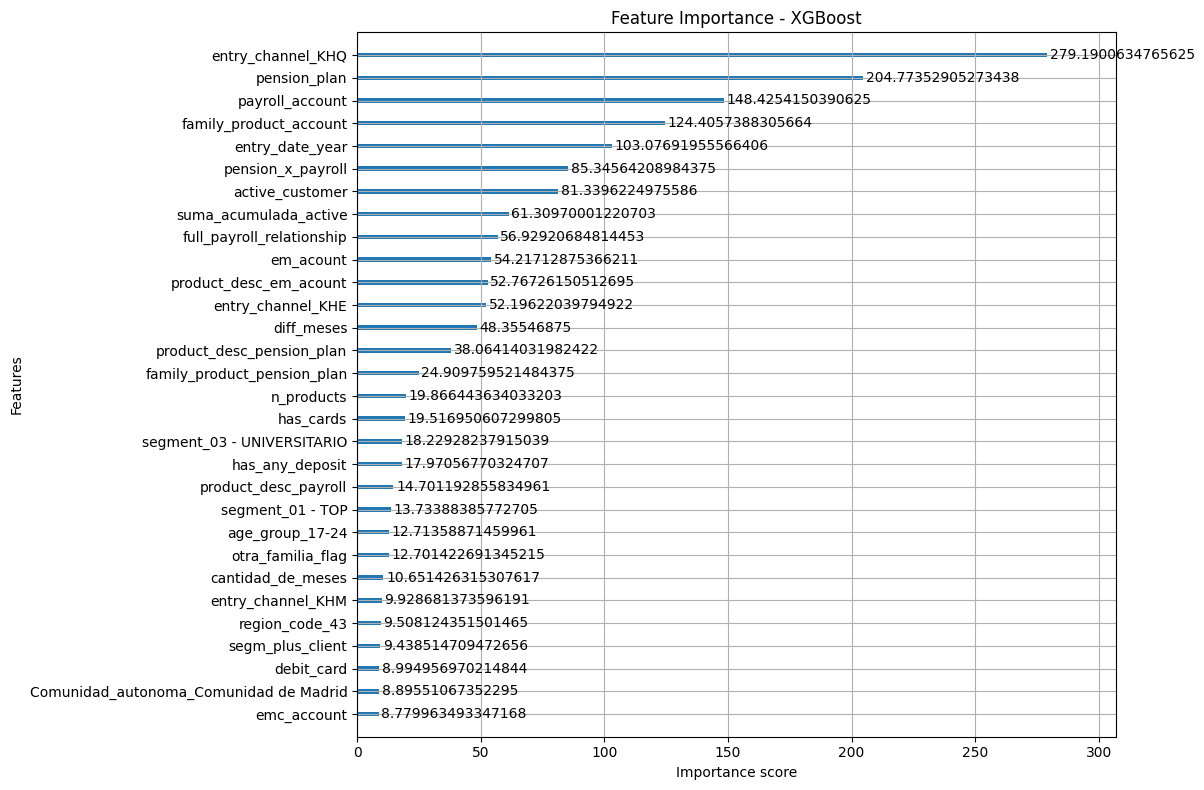

In [21]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

fig, ax = plt.subplots(figsize=(12, 8))

plot_importance(
    model,
    max_num_features=30,
    importance_type='gain',
    ax=ax
)

ax.set_title("Feature Importance - XGBoost")
plt.tight_layout()
plt.savefig(
    f"results/plots/Feature_Importance_{model.__class__.__name__}.png", dpi=300)

plt.show()
